<a href="https://colab.research.google.com/github/Iram123S/Intrusion-Detection-System/blob/main/AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AUTOENCODER BASED AND
NETBERT BASED INTRUSION
DETECTION SYSTEM**

Saving Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv to Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX (1).csv


/tmp/ipython-input-4142849689.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_labels = binary_labels.replace({'BENIGN': 0, 'Attack': 1})
/tmp/ipython-input-4142849689.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.replace([np.inf, -np.inf], np.nan).fillna(method='ffill').values


[AE] Epoch 1 | Loss: 7.6052
[AE] Epoch 2 | Loss: 0.7899
[AE] Epoch 3 | Loss: 0.4522
[AE] Epoch 4 | Loss: 0.3407
[AE] Epoch 5 | Loss: 0.2787
AE Threshold: 0.004317
[Classifier] Epoch 1 | Loss: 71.7238
[Classifier] Epoch 2 | Loss: 41.2174
[Classifier] Epoch 3 | Loss: 30.9122
[Classifier] Epoch 4 | Loss: 24.6033
[Classifier] Epoch 5 | Loss: 20.5287

--- Hybrid NIDS Report ---
Accuracy           : 0.9495
Precision          : 0.0017
Recall (TPR)       : 0.7143
False Alarm Rate   : 0.0505
True Negative Rate : 0.9495


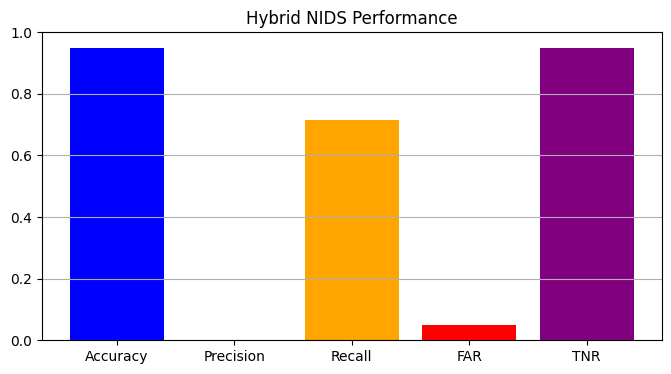

In [ ]:
# ===================== Imports =====================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

from google.colab import files
import io

# ===================== Reproducibility =====================
torch.manual_seed(42)
np.random.seed(42)

# ===================== Load Data =====================
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), low_memory=False)

df.columns = df.columns.str.strip()

labels = df['Label'].copy()
binary_labels = labels.replace(to_replace=r'^(?!BENIGN$).*', value='Attack', regex=True)
binary_labels = binary_labels.replace({'BENIGN': 0, 'Attack': 1})
y = binary_labels.values

X = df.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan).fillna(method='ffill').values

# ===================== Train / Test Split (NO leakage) =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pt = PowerTransformer()
X_train = pt.fit_transform(X_train)
X_test = pt.transform(X_test)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===================== Torch Setup =====================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 1024

def to_loader(X, y=None, shuffle=True):
    X = torch.tensor(X, dtype=torch.float32)
    if y is not None:
        y = torch.tensor(y, dtype=torch.long)
        dataset = torch.utils.data.TensorDataset(X, y)
    else:
        dataset = torch.utils.data.TensorDataset(X)
    return torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
test_loader  = to_loader(X_test, y_test, shuffle=False)

# ===================== Models =====================
class FlowAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16)
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


class NetTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.embedding = nn.Linear(input_dim, 32)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=32, nhead=4, batch_first=True
            ),
            num_layers=1
        )
        self.classifier = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)   # (B, 1, 32)
        x = self.transformer(x).squeeze(1)  # (B, 32)
        return self.classifier(x)

# ===================== Train Autoencoder (Benign Only) =====================
ae = FlowAutoencoder(X_train.shape[1]).to(device)
ae_opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
ae_loss = nn.MSELoss()

for epoch in range(5):
    ae.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb = Xb[yb == 0].to(device)
        if Xb.nelement() == 0:
            continue

        recon, _ = ae(Xb)
        loss = ae_loss(recon, Xb)

        ae_opt.zero_grad()
        loss.backward()
        ae_opt.step()

        total_loss += loss.item()

    print(f"[AE] Epoch {epoch+1} | Loss: {total_loss:.4f}")

# ===================== AE Threshold (95th percentile) =====================
ae.eval()
errors = []

with torch.no_grad():
    for Xb, yb in train_loader:
        Xb = Xb[yb == 0].to(device)
        if Xb.nelement() == 0:
            continue
        recon, _ = ae(Xb)
        err = ((recon - Xb) ** 2).mean(dim=1)
        errors.extend(err.cpu().numpy())

ae_thresh = np.percentile(errors, 95)
print(f"AE Threshold: {ae_thresh:.6f}")

# ===================== Train Classifier =====================
net = NetTransformer(X_train.shape[1]).to(device).float()

# class imbalance handling
n_benign = (y_train == 0).sum()
n_attack = (y_train == 1).sum()
weights = torch.tensor([1.0, n_benign / n_attack], dtype=torch.float32).to(device)

clf_loss = nn.CrossEntropyLoss(weight=weights)
clf_opt = torch.optim.Adam(net.parameters(), lr=1e-4)

for epoch in range(5):
    net.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        out = net(Xb)
        loss = clf_loss(out, yb)

        clf_opt.zero_grad()
        loss.backward()
        clf_opt.step()

        total_loss += loss.item()

    print(f"[Classifier] Epoch {epoch+1} | Loss: {total_loss:.4f}")

# ===================== Hybrid Evaluation =====================
def hybrid_decision(ae, net, dataloader, ae_thresh):
    ae.eval()
    net.eval()

    preds, labels = [], []

    with torch.no_grad():
        for Xb, yb in dataloader:
            Xb = Xb.to(device)

            recon, _ = ae(Xb)
            ae_err = ((recon - Xb) ** 2).mean(dim=1)
            ae_pred = ae_err > ae_thresh

            logits = net(Xb)
            probs = F.softmax(logits, dim=1)[:, 1]
            net_pred = probs > 0.5

            final_pred = (ae_pred | net_pred).int()

            preds.extend(final_pred.cpu().numpy())
            labels.extend(yb.numpy())

    return np.array(labels), np.array(preds)

y_true, y_pred = hybrid_decision(ae, net, test_loader, ae_thresh)

# ===================== Metrics =====================
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
far  = fp / (fp + tn + 1e-8)
tnr  = tn / (tn + fp + 1e-8)

print("\n--- Hybrid NIDS Report ---")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {prec:.4f}")
print(f"Recall (TPR)       : {rec:.4f}")
print(f"False Alarm Rate   : {far:.4f}")
print(f"True Negative Rate : {tnr:.4f}")

# ===================== Visualization =====================
metrics = ['Accuracy', 'Precision', 'Recall', 'FAR', 'TNR']
values = [acc, prec, rec, far, tnr]

plt.figure(figsize=(8,4))
plt.bar(metrics, values, color=['blue','green','orange','red','purple'])
plt.ylim(0,1)
plt.title("Hybrid NIDS Performance")
plt.grid(axis='y')
plt.show()

Saving Wednesday-workingHours.pcap_ISCX.csv to Wednesday-workingHours.pcap_ISCX.csv


/tmp/ipykernel_5875/4069146331.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_labels = binary_labels.replace({'BENIGN': 0, 'Attack': 1})
/tmp/ipykernel_5875/4069146331.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = df.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(method='ffill')


[AE] Epoch 1: Loss=13.7335
[AE] Epoch 2: Loss=1.8072
[AE] Epoch 3: Loss=1.1883
[AE] Epoch 4: Loss=0.8630
[AE] Epoch 5: Loss=0.6388


/tmp/ipykernel_5875/4069146331.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(


[NetBERT] Epoch 1: Loss=81.4174
[NetBERT] Epoch 2: Loss=14.4529
[NetBERT] Epoch 3: Loss=9.0754
[NetBERT] Epoch 4: Loss=7.0953
[NetBERT] Epoch 5: Loss=5.9242

--- Hybrid Detection Report ---
Accuracy           : 0.9975
Precision          : 0.9936
Recall (TPR)       : 0.9995
False Alarm Rate   : 0.0037
True Negative Rate : 0.9963


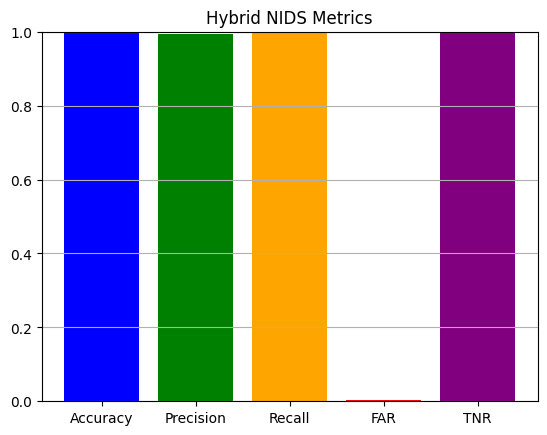

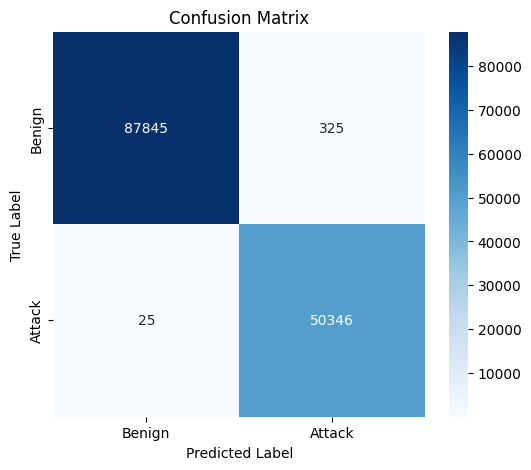

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from google.colab import files
import io


uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), low_memory=False)

df.columns = df.columns.str.strip()
labels = df['Label'].copy()
binary_labels = labels.replace(to_replace=r'^(?!BENIGN$).*', value='Attack', regex=True)
binary_labels = binary_labels.replace({'BENIGN': 0, 'Attack': 1})
y = binary_labels.values

X = df.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(method='ffill')
pt = PowerTransformer()
X = pt.fit_transform(X)
X = MinMaxScaler().fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 1024


def to_loader(X, y=None):
    tensor_X = torch.FloatTensor(X)
    if y is not None:
        tensor_y = torch.LongTensor(y)
        dataset = torch.utils.data.TensorDataset(tensor_X, tensor_y)
    else:
        dataset = torch.utils.data.TensorDataset(tensor_X)
    return torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

train_loader = to_loader(X_train, y_train)
test_loader = to_loader(X_test, y_test)

class FlowAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 32), nn.ReLU(), nn.Linear(32, 16))
        self.decoder = nn.Sequential(nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, input_dim))
    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent

class NetBERT(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.embedding = nn.Linear(input_dim, 32)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=32, nhead=4), num_layers=1)
        self.classifier = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 2))
    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = self.transformer(x).squeeze(1)
        return self.classifier(x)

ae = FlowAutoencoder(X.shape[1]).to(device)
ae_opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
ae_loss = nn.MSELoss()

for epoch in range(5):
    ae.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X = batch_X[batch_y == 0].to(device)
        if batch_X.nelement() == 0: continue
        recon, _ = ae(batch_X)
        loss = ae_loss(recon, batch_X)
        ae_opt.zero_grad()
        loss.backward()
        ae_opt.step()
        total_loss += loss.item()
    print(f"[AE] Epoch {epoch+1}: Loss={total_loss:.4f}")


netbert = NetBERT(X.shape[1]).to(device)
clf_opt = torch.optim.Adam(netbert.parameters(), lr=1e-4)
clf_loss = nn.CrossEntropyLoss()

for epoch in range(5):
    netbert.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        out = netbert(batch_X)
        loss = clf_loss(out, batch_y)
        clf_opt.zero_grad()
        loss.backward()
        clf_opt.step()
        total_loss += loss.item()
    print(f"[NetBERT] Epoch {epoch+1}: Loss={total_loss:.4f}")

def hybrid_decision(autoencoder, netbert, dataloader, ae_thresh=0.04):
    autoencoder.eval()
    netbert.eval()
    all_preds, all_labels = [], []
    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device)
        recon, _ = autoencoder(batch_X)
        recon_error = ((recon - batch_X)**2).mean(dim=1)
        ae_pred = recon_error > ae_thresh
        out = netbert(batch_X)
        probs = F.softmax(out, dim=1)[:, 1]
        netbert_pred = probs > 0.5
        final_pred = (ae_pred | netbert_pred).int()
        all_preds.extend(final_pred.cpu().numpy())
        all_labels.extend(batch_y.numpy())
    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = hybrid_decision(ae, netbert, test_loader)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
far = fp / (fp + tn + 1e-6)
tnr = tn / (tn + fp + 1e-6)

# === Report ===
print("\n--- Hybrid Detection Report ---")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {prec:.4f}")
print(f"Recall (TPR)       : {rec:.4f}")
print(f"False Alarm Rate   : {far:.4f}")
print(f"True Negative Rate : {tnr:.4f}")

# === Visualize ===
metrics = ['Accuracy', 'Precision', 'Recall', 'FAR', 'TNR']
values = [acc, prec, rec, far, tnr]
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.title("Hybrid NIDS Metrics")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
